# Otsu Thresholding and Selective Histogram Equalization

In [1]:
# Import required libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Set up matplotlib
plt.style.use('default')
%matplotlib inline


## Load and Convert to Grayscale

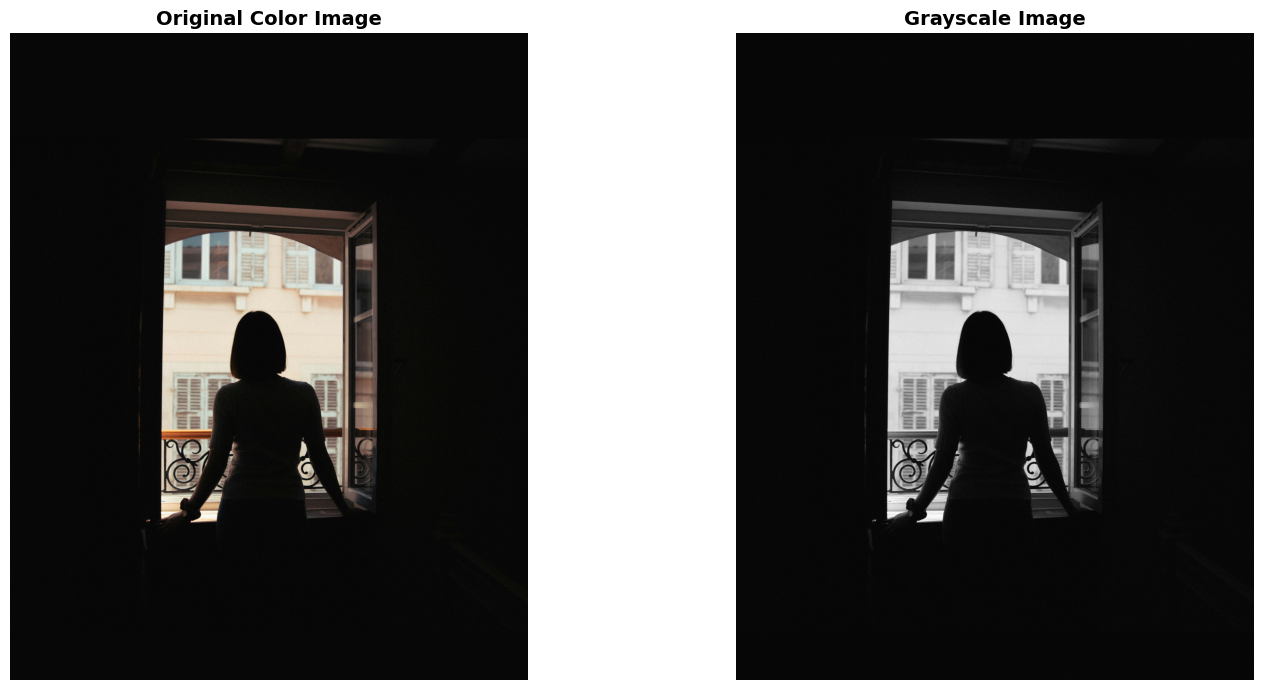

Image shape: (5867, 4693)
Intensity range: [0, 255]


In [ ]:
# Load the image
if img_bgr is None:
    img_bgr = cv2.imread('img/woman.jpg')
    
if img_bgr is None:
    raise FileNotFoundError("woman.jpg not found")

# Convert to RGB for display
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Convert to grayscale
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

# Display original color and grayscale images
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].imshow(img_rgb)
axes[0].set_title('Original Color Image', fontsize=14, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(img_gray, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('Grayscale Image', fontsize=14, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()

print(f"Image shape: {img_gray.shape}")
print(f"Intensity range: [{img_gray.min()}, {img_gray.max()}]")


## (a) Otsu Thresholding for Foreground Binary Mask

**Otsu's Method** automatically determines the optimal threshold value by maximizing the between-class variance of the pixel intensities.

The method separates:
- **Foreground**: Woman and room interior (darker regions)
- **Background**: Bright window and outside view

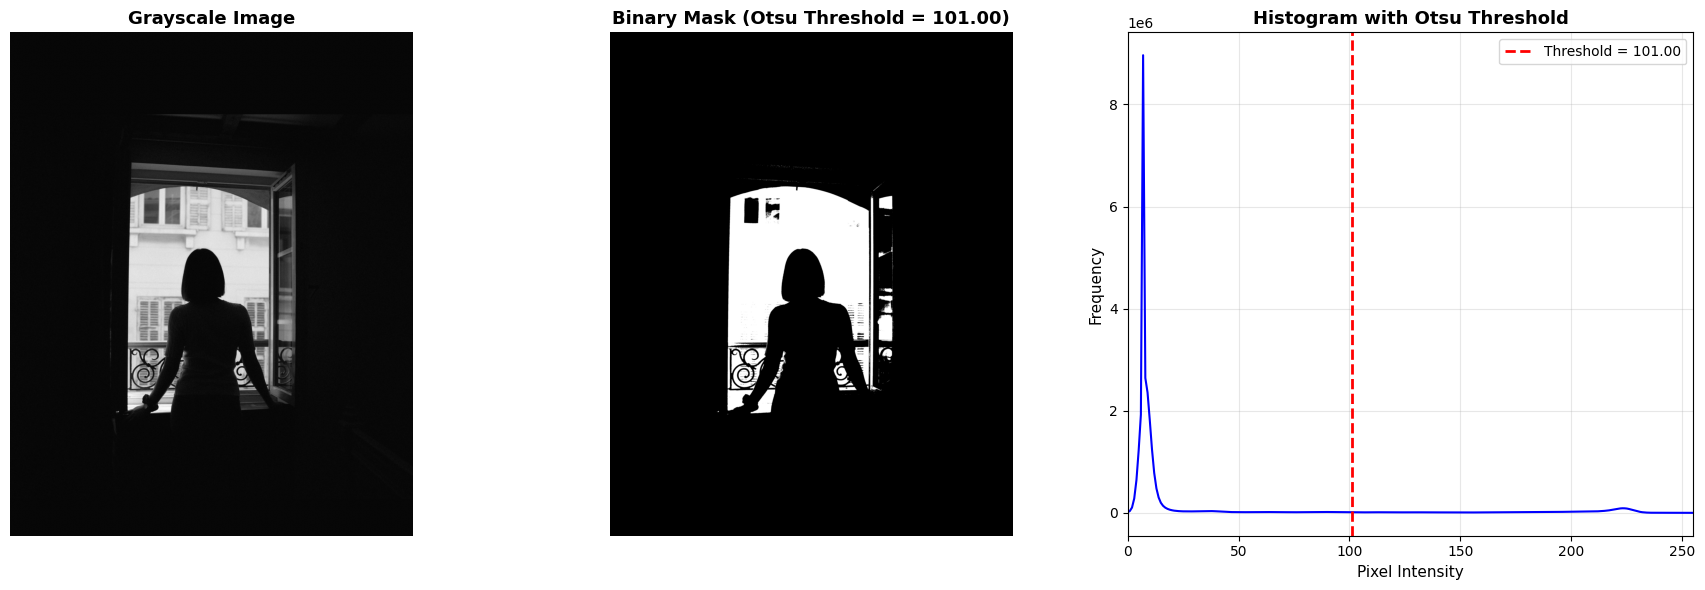

OTSU THRESHOLDING RESULTS:
Optimal Threshold Value: 101.00
Binary Mask: White (255) = Foreground, Black (0) = Background
Foreground pixels: 2,551,467 (9.27%)
Background pixels: 24,982,364 (90.73%)


In [5]:
# Apply Otsu's thresholding
threshold_value, binary_mask = cv2.threshold(img_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Display results
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(img_gray, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Grayscale Image', fontsize=13, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(binary_mask, cmap='gray', vmin=0, vmax=255)
axes[1].set_title(f'Binary Mask (Otsu Threshold = {threshold_value:.2f})', fontsize=13, fontweight='bold')
axes[1].axis('off')

# Display histogram with threshold line
hist = cv2.calcHist([img_gray], [0], None, [256], [0, 256])
axes[2].plot(hist, color='blue', linewidth=1.5)
axes[2].axvline(x=threshold_value, color='red', linestyle='--', linewidth=2, label=f'Threshold = {threshold_value:.2f}')
axes[2].set_title('Histogram with Otsu Threshold', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Pixel Intensity', fontsize=11)
axes[2].set_ylabel('Frequency', fontsize=11)
axes[2].legend()
axes[2].grid(True, alpha=0.3)
axes[2].set_xlim([0, 255])

plt.tight_layout()
plt.show()

print("OTSU THRESHOLDING RESULTS:")
print(f"Optimal Threshold Value: {threshold_value:.2f}")
print(f"Binary Mask: White (255) = Foreground, Black (0) = Background")
print(f"Foreground pixels: {np.sum(binary_mask == 255):,} ({np.sum(binary_mask == 255)/binary_mask.size*100:.2f}%)")
print(f"Background pixels: {np.sum(binary_mask == 0):,} ({np.sum(binary_mask == 0)/binary_mask.size*100:.2f}%)")


## (b) Selective Histogram Equalization on Foreground

Apply histogram equalization only to the foreground region while keeping the background.

In [6]:
# Create a mask for foreground pixels
foreground_mask = (binary_mask == 255)

# Extract foreground pixels
foreground_pixels = img_gray[foreground_mask]

# Apply histogram equalization to foreground pixels only
foreground_equalized = cv2.equalizeHist(foreground_pixels.reshape(-1, 1)).flatten()

# Create output image
img_selective_equalized = img_gray.copy()

# Replace foreground pixels with equalized values
img_selective_equalized[foreground_mask] = foreground_equalized

print("Selective histogram equalization applied to foreground region!")
print(f"Foreground pixels processed: {len(foreground_pixels):,}")
print(f"Original foreground range: [{foreground_pixels.min()}, {foreground_pixels.max()}]")
print(f"Equalized foreground range: [{foreground_equalized.min()}, {foreground_equalized.max()}]")


Selective histogram equalization applied to foreground region!
Foreground pixels processed: 2,551,467
Original foreground range: [102, 255]
Equalized foreground range: [0, 255]


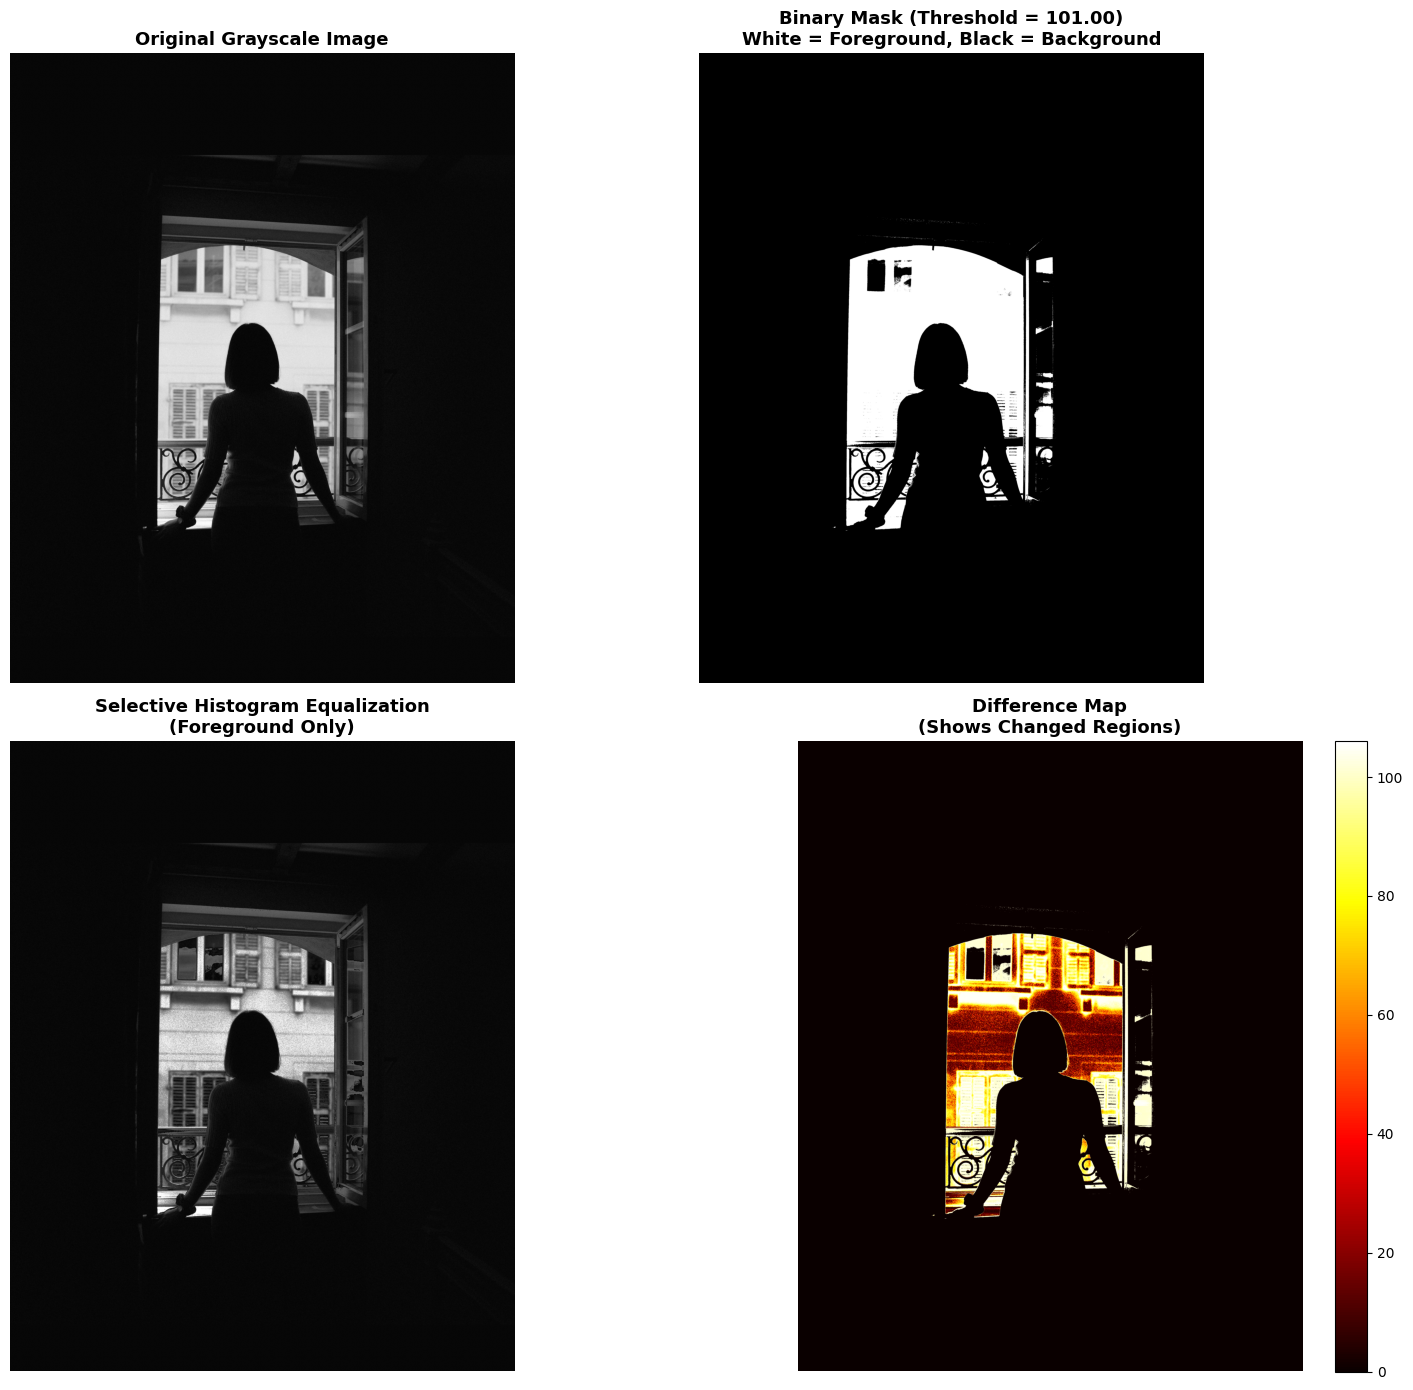

In [7]:
# Compare original and selectively equalized images
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# Original grayscale
axes[0, 0].imshow(img_gray, cmap='gray', vmin=0, vmax=255)
axes[0, 0].set_title('Original Grayscale Image', fontsize=13, fontweight='bold')
axes[0, 0].axis('off')

# Binary mask showing foreground/background separation
axes[0, 1].imshow(binary_mask, cmap='gray', vmin=0, vmax=255)
axes[0, 1].set_title(f'Binary Mask (Threshold = {threshold_value:.2f})\nWhite = Foreground, Black = Background', 
                     fontsize=13, fontweight='bold')
axes[0, 1].axis('off')

# Selectively equalized image
axes[1, 0].imshow(img_selective_equalized, cmap='gray', vmin=0, vmax=255)
axes[1, 0].set_title('Selective Histogram Equalization\n(Foreground Only)', fontsize=13, fontweight='bold')
axes[1, 0].axis('off')

# Difference visualization
difference = np.abs(img_selective_equalized.astype(int) - img_gray.astype(int))
axes[1, 1].imshow(difference, cmap='hot', vmin=0, vmax=difference.max())
axes[1, 1].set_title('Difference Map\n(Shows Changed Regions)', fontsize=13, fontweight='bold')
axes[1, 1].axis('off')
plt.colorbar(axes[1, 1].images[0], ax=axes[1, 1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


## Histogram Comparison

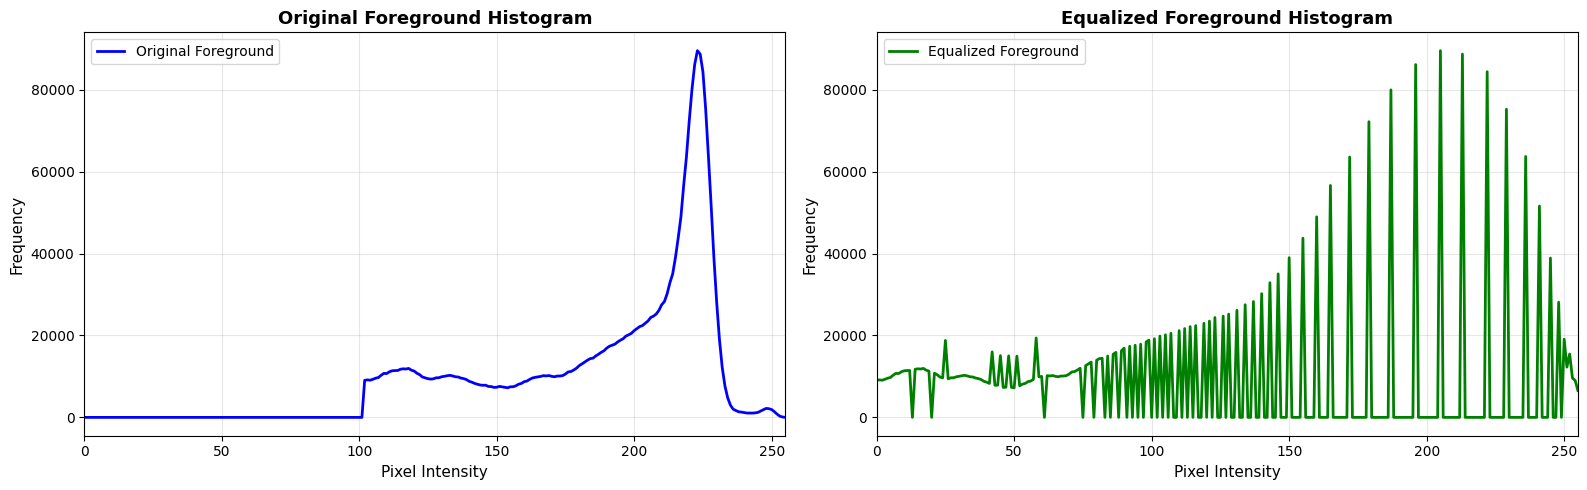

In [9]:
# Calculate histograms
hist_original_fg = cv2.calcHist([img_gray], [0], binary_mask, [256], [0, 256])
hist_equalized_fg = cv2.calcHist([img_selective_equalized], [0], binary_mask, [256], [0, 256])

# Plot histogram comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Original foreground histogram
axes[0].plot(hist_original_fg, color='blue', linewidth=2, label='Original Foreground')
axes[0].set_title('Original Foreground Histogram', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Pixel Intensity', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim([0, 255])

# Equalized foreground histogram
axes[1].plot(hist_equalized_fg, color='green', linewidth=2, label='Equalized Foreground')
axes[1].set_title('Equalized Foreground Histogram', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Pixel Intensity', fontsize=11)
axes[1].set_ylabel('Frequency', fontsize=11)
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim([0, 255])

plt.tight_layout()
plt.show()